In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If Biopython is available – strongly recommended for mmCIF
from Bio.PDB.MMCIF2Dict import MMCIF2Dict

CIF_DIR = Path("cif")
NPZ_DIR = Path("npz")

In [9]:
def extract_sequence_from_cif(cif_path: Path) -> str:
    """
    Extract one-letter amino-acid sequence from an mmCIF file.

    Uses _entity_poly.pdbx_seq_one_letter_code(_can), which is what AF-style
    outputs usually store.
    """
    d = MMCIF2Dict(str(cif_path))

    seq_field = (
        d.get("_entity_poly.pdbx_seq_one_letter_code_can")
        or d.get("_entity_poly.pdbx_seq_one_letter_code")
    )
    if seq_field is None:
        raise ValueError(f"No sequence field found in CIF: {cif_path}")

    # Biopython may return list or str; normalise to a single string
    if isinstance(seq_field, list):
        seq = "".join(seq_field)
    else:
        seq = str(seq_field)

    # Remove whitespace/newlines
    seq = "".join(seq.split())
    return seq


records = []
for cif_path in sorted(CIF_DIR.glob("hallucination_*.cif")):
    name = cif_path.stem                 # e.g. "hallucination_00"
    idx = int(name.split("_")[1])        # 0, 1, ...

    try:
        seq = extract_sequence_from_cif(cif_path)
    except Exception as e:
        print(f"Failed to parse {cif_path}: {e}")
        continue

    records.append(
        {
            "hallucination_id": name,
            "index": idx,
            "sequence": seq,
            "length": len(seq),
        }
    )

seq_df = pd.DataFrame(records).sort_values("index").reset_index(drop=True)
seq_df.head()
seq_df.to_csv("hallucination_sequences.csv", index=False)

In [11]:
import csv

def csv_to_fasta(csv_path, fasta_path, seq_col="sequence", name_col="index"):
    with open(csv_path, newline='') as csvfile, open(fasta_path, "w") as fasta:
        reader = csv.DictReader(csvfile)
        for row in reader:
            seq = row.get(seq_col, "").strip()
            name = row.get(name_col, "").strip()
            if seq:
                if not name:
                    name = "unranked"
                fasta.write(f">seq_rank_{name}\n{seq}\n")

# Example usage:
csv_to_fasta("hallucination_sequences.csv", "hallucination_sequences.fasta")

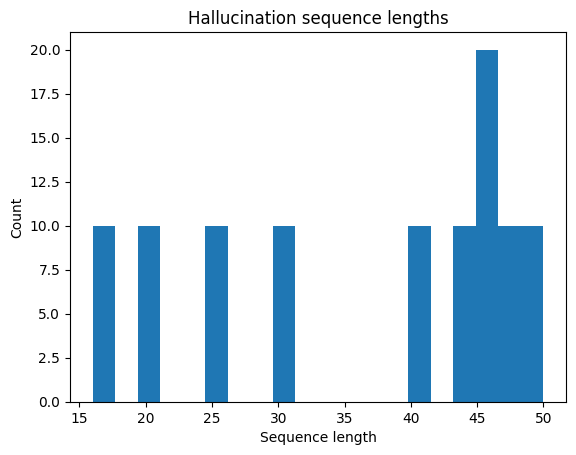

In [3]:
plt.hist(seq_df["length"], bins=20)
plt.xlabel("Sequence length")
plt.ylabel("Count")
plt.title("Hallucination sequence lengths")
plt.show()

In [4]:
def load_hallucination_npz(idx: int):
    """
    Load the .npz file for a given hallucination index and return (path, npz-object).

    Prints the stored array names so you can choose what to plot.
    """
    npz_path = NPZ_DIR / f"hallucination_{idx:02d}.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"No npz file for hallucination {idx}: {npz_path}")

    data = np.load(npz_path)
    print(f"{npz_path} keys:", data.files)
    return npz_path, data

In [5]:
npz_path, data = load_hallucination_npz(0)

npz/hallucination_00.npz keys: ['design_mask', 'inverse_fold_design_mask', 'mol_type', 'ss_type', 'token_resolved_mask', 'binding_type']


In [8]:
print(data['design_mask'])
# print(data['inverse_fold_design_mask'])
print(data['mol_type'])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0]
